# 04 — Evaluation harness

**Demonstrates:** threshold selection on validation only, the headline test metrics with
bootstrap 95% CIs, ROC/PR/confusion figures, the threshold sweep, and the cross-dataset
generalisation table (and its drop on the zero-shot AIRTLab row). All numbers below are computed
live, in this notebook, from the committed `lstm_head_baseline` checkpoint and the Phase 1 feature
store, then checked against the committed `artifacts/reports/eval_*.json`.

**Maps to:** report §2.10 (accuracy/precision/recall/F1/ROC-AUC on held-out and cross-dataset
splits), `docs/SPRINT_PLAN.md` Sprint 2.


In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json  # noqa: E402

import pandas as pd  # noqa: E402
import yaml  # noqa: E402

from safestreets.evaluation.evaluate import load_checkpoint, score_split  # noqa: E402
from safestreets.evaluation.metrics import (  # noqa: E402
    compute_metrics,
    select_f1_optimal,
    threshold_sweep,
)


/opt/anaconda3/envs/safestreets/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/10/10 17:09:50 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /opt/anaconda3/envs/safestreets/lib/python3.11/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


/opt/anaconda3/envs/safestreets/lib/python3.11/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error timed out>
  data = fetch_version_info()


## Load the shipped-for-evaluation checkpoint and score every split

Scoring uses the Sprint 1 `lstm_head_baseline` checkpoint (the one `docs/RESULTS.md`'s headline numbers describe; Sprint 4's AIRTLab-fine-tuned checkpoint is a separate, later decision, covered in notebook 05) over the precomputed MobileNetV2 feature store.

In [2]:
model = load_checkpoint("artifacts/checkpoints/lstm_head_baseline.keras")

y_val, s_val, _ = score_split(model, "data/features", ["rwf2000", "rlvs"], "val")
y_test, s_test, _ = score_split(model, "data/features", ["rlvs", "airtlab", "ucfcrime"], "test")
print(f"val: n={len(y_val)}  test (rlvs+airtlab+ucfcrime): n={len(y_test)}")


2026-10-10 17:10:00.451591: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-10-10 17:10:00.451620: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-10-10 17:10:00.451625: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-10-10 17:10:00.451648: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-10-10 17:10:00.451663: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


2026-10-10 17:10:05.690322: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


val: n=673  test (rlvs+airtlab+ucfcrime): n=325


## Threshold selection, validation only

Both operating points are chosen on `val`; `test` below is touched only to report the headline numbers, never to pick a threshold (CLAUDE.md's "test touched once" discipline).

In [3]:
sweep = threshold_sweep(y_val, s_val)
f1_threshold = select_f1_optimal(sweep)
print(f"F1-optimal threshold selected on val: {f1_threshold:.4f}")

infer_cfg = yaml.safe_load(Path("configs/infer.yaml").read_text())
assert abs(f1_threshold - infer_cfg["threshold"]) < 1e-6, "disagrees with configs/infer.yaml"
print(f"matches the persisted configs/infer.yaml threshold: {infer_cfg['threshold']}")


F1-optimal threshold selected on val: 0.2000
matches the persisted configs/infer.yaml threshold: 0.2


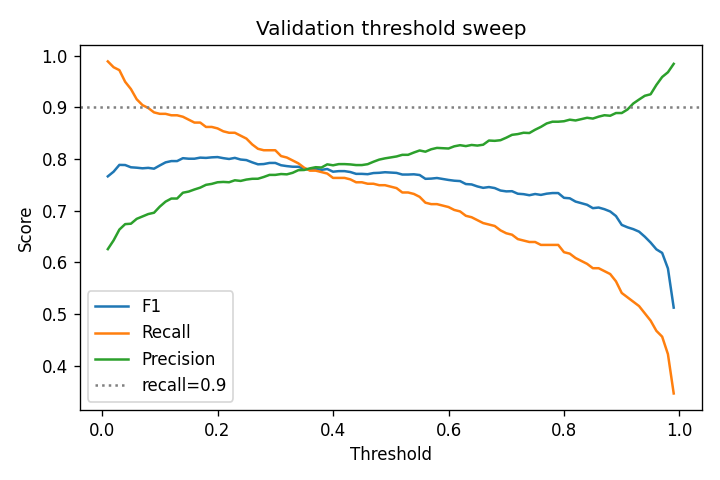

In [4]:
from IPython.display import Image

Image(filename=str(REPO_ROOT / "artifacts" / "figures" / "threshold_sweep.png"))


## Headline test metrics

Computed live, with 1000-resample bootstrap 95% CIs, at the val-selected threshold above.

In [5]:
live_metrics = compute_metrics(y_test, s_test, f1_threshold, n_resamples=1000)
committed = json.loads(Path("artifacts/reports/eval_test.json").read_text())

rows = []
for name in ["roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1"]:
    rows.append({
        "metric": name,
        "live": round(live_metrics[name]["value"], 4),
        "committed": round(committed[name]["value"], 4),
    })
df = pd.DataFrame(rows)
rescore_matches = (df["live"].round(2) == df["committed"].round(2)).all()
assert rescore_matches, "live re-score disagrees with the committed report"
df


,metric,live,committed
0,roc_auc,0.9450,0.9450
1,pr_auc,0.9471,0.9471
2,accuracy,0.8769,0.8769
3,precision,0.8392,0.8392
4,recall,0.9543,0.9543
5,f1,0.8930,0.8930


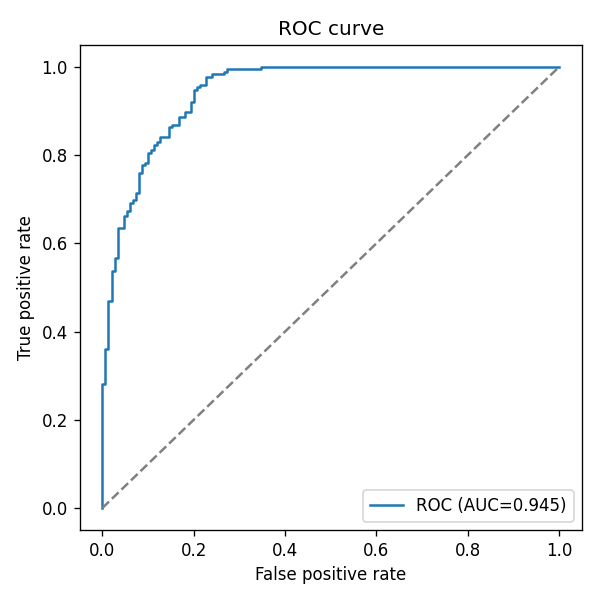

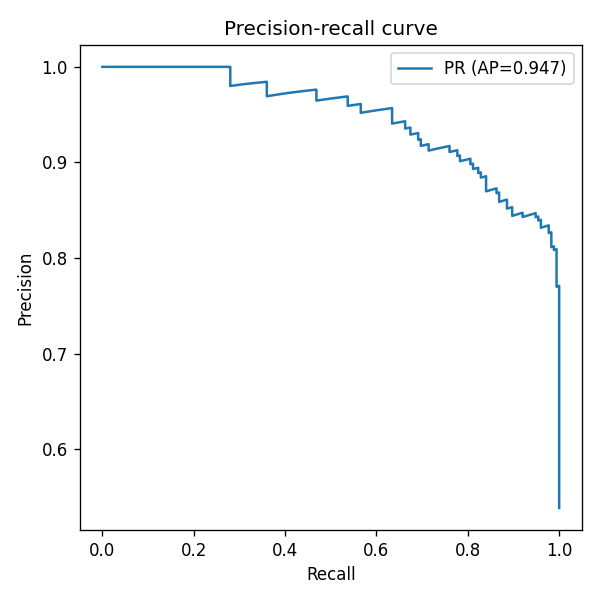

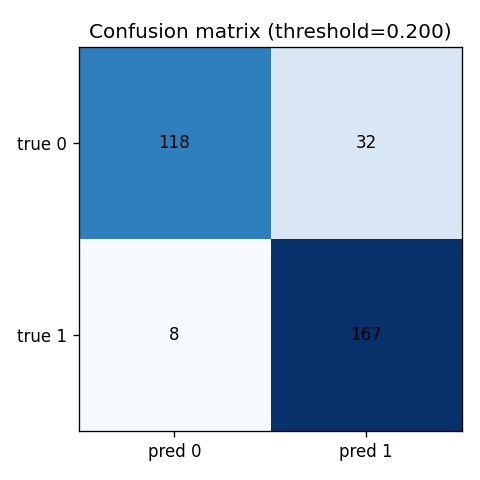

In [6]:
from IPython.display import Image as _Image

for fig in ["roc.png", "pr.png", "confusion.png"]:
    display(_Image(filename=str(REPO_ROOT / "artifacts" / "figures" / fig)))


## Cross-dataset generalisation

The model trains on `rwf2000 + rlvs` only. RLVS test is in-domain; AIRTLab and UCF-Crime are zero-shot: the model never saw either during training. This is the gap that motivates Sprint 4's AIRTLab fine-tune (notebook 05).

In [7]:
cross = json.loads(Path("artifacts/reports/cross_dataset.json").read_text())
cross_cols = ["test_dataset", "in_domain", "n", "roc_auc", "auc_drop_vs_in_domain"]
cross_df = pd.DataFrame(cross["rows"])[cross_cols]
cross_df


,test_dataset,in_domain,n,roc_auc,auc_drop_vs_in_domain
0,rlvs,True,272,0.980510,NaN
1,airtlab,False,48,0.525926,0.454584
2,ucfcrime,False,5,1.000000,-0.019490


## Limitations

- **Frame-level AUC on untrimmed video is out of scope.** XD-Violence was never fetched (38.3 GB,
  over budget) and the UCF-Crime subset holds 35 clips total, too few for a meaningful
  frame-level number. See `docs/SPRINT_PLAN.md` §2 and `docs/RESULTS.md`.
- **AIRTLab's zero-shot row (0.53 AUC) reflects a *filming style* shift** (acted/staged footage
  vs. RWF-2000/RLVS's organic clips), not necessarily a harder violence-detection task; read it
  with that caveat.
- **UCF-Crime's test split is 5 clips** (1 negative, 4 positive); its row's CI is wide or
  undefined purely from sample size, not a modelling claim.
